In [33]:
#Importing required libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import pandas as pd

df = pd.read_csv('/content/vgsales.csv')
df

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37
...,...,...,...,...,...,...,...,...,...,...,...
20373,16596,Woody Woodpecker in Crazy Castle 5,GBA,2002.0,Platform,Kemco,0.01,0.00,0.00,0.00,0.01
20374,16597,Men in Black II: Alien Escape,GC,2003.0,Shooter,Infogrames,0.01,0.00,0.00,0.00,0.01
20375,16598,SCORE International Baja 1000: The Official Game,PS2,2008.0,Racing,Activision,0.00,0.00,0.00,0.00,0.01
20376,16599,Know How 2,DS,2010.0,Puzzle,7G//AMES,0.00,0.01,0.00,0.00,0.01


In [42]:
# Select features and target
features = ['NA_Sales']
target = 'Global_Sales'

# Drop rows with any NaN values in the selected features or target columns
df_clean = df.dropna(subset=features + [target])

# Find and remove the top 5 rows with the maximum NA_Sales as outliers
max_na_sales_indices = df_clean['NA_Sales'].nlargest(5).index
df_clean = df_clean.drop(max_na_sales_indices)

x = df_clean[features]
y = df_clean[target]

# Splitting into training and test set
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42) #80% training 20%testing

In [43]:
#Initializing the Linear Regression Model
model = LinearRegression()

model.fit(x_train, y_train)

#Making Predictions
y_pred = model.predict(x_test)

#Calculate the MSE (Mean squared error) as a metrix
mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error: ", mse)

print("Test R2 Score: ", r2_score(y_test, y_pred))

Mean Squared Error:  0.14183126575467553
Test R2 Score:  0.9110631826003681


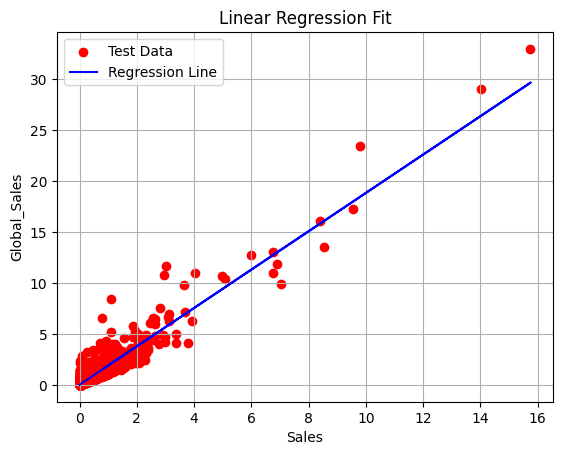

In [44]:
#Visualizing the data and the regression line
plt.scatter(x_test, y_test, color='red', label='Test Data')
plt.plot(x_test, y_pred, color='blue', label='Regression Line')

plt.xlabel('Sales')
plt.ylabel('Global_Sales') # Label for the target variable
plt.title('Linear Regression Fit')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
#Print the coefficients (intercept and slope)
print(f"Intercept: {model.intercept_}")
print(f"Slope: {model.coef_[0]}")
print(f"Mean squared error: {mean_squared_error(y_test, y_pred)}")

Intercept: 0.06940141787931653
Slope: 1.722168884739447
Mean squared error: 0.25444975168822404
